# Análise Exploratória de Dados (EDA)
## Projeto: Classificação ESG por Machine Learning
**Empresa:** NorthData Consulting  
**Dataset:** Public Company ESG Ratings  
**Fonte:** https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset  
**Autor:** Phelipe C. S. Cota 
**Data:** 26/05/2026  

---

### Objetivo
Realizar a análise exploratória do dataset de ratings ESG de empresas públicas,
identificando padrões, inconsistências e insights que orientarão a modelagem de
Machine Learning para classificação e gestão de risco de fornecedores.

### Estrutura do Notebook
1. Preparação do ambiente
2. Leitura da Base de Dados
3. Visão geral do dataset
4. Qualidade dos dados
5. Estatísticas Descritivas
6. Insights e conclusões

## 1. Preparação do ambiente

In [1]:
#Bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Configurações de exibição

pd.set_option("display.max_columns", None)   # mostra todas as colunas
pd.set_option("display.float_format", "{:.2f}".format)  #2 casas decimais

sns.set_theme(style="whitegrid", palette="muted") #gráficos com fundo branco e grade discreta, cores suaves e menos saturadas   
plt.rcParams["figure.figsize"] = (12, 5) #tamanho padrão das figuras

## 2. Leitura da Base de Dados

Os dados serão extraídos via script de ingestão (src\ingest_data.py) diretamente do Kaggle$^1$, que serão salvos em máquina local, primeiramente na pasta \data\bronze, seguindo a filosofia da arquitetura medalhão para estruturar o pipeline de dados.

$^1$Consultar a sessão **FASE I - Extraindo dos Dados** no arquivo README.md

##Integridade dos Dados (Hash MD5)

Foi incluído o hash MD5 (Message Digest 5) para gerar um código único de 32 caracteres (hexadecimal) para garantir a integridade da base de dados baixada. Este código garante rastreabilidade quanto a alterações na base de dado, caso venha a ocorrer qualquer adulteração no dado e mudanças futuras em sua forma ou erro no download, o código gerado será outro.

##Metadata

Gerado arquivo .json com as informações de nome do arquivo, diretório em máquina local, URL de origem, data de ingestão e código MD5 hash gerado, para autidotiras futuras.

>*Arquivo metadata gerado:*   
 {  
    "arquivo": "data.csv",  
    "fonte_original": "https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset",  
    "data_ingestao": "2026-05-26T22:38:56.999270",  
    "md5_hash": "68848e9627b67d88c8839c9a24e70049",  
    "metodo": "Kaggle API"  
}

In [2]:
from pathlib import Path

# Caminho relativo à raiz do projeto
BRONZE_DIR = Path("..") / "data" / "bronze"
df = pd.read_csv(BRONZE_DIR / "data.csv")

print(f"Formato do dataset carregado:")
print(f"   Linhas  : {df.shape[0]:,}")
print(f"   Colunas : {df.shape[1]}")

Formato do dataset carregado:
   Linhas  : 722
   Colunas : 21


## 3. Visão geral do dataset

In [3]:
# Primeiras linhas do dataset
print("=" * 50)
print("PRIMEIRAS 10 LINHAS:")
print("=" * 50)

display(df.head(10))

# Tipos de dados de cada coluna
print("\n")
print("=" * 50)
print("TIPOS DE DADOS POR COLUNA:")
print("=" * 50)
print(df.dtypes)



PRIMEIRAS 10 LINHAS:


,ticker,name,currency,exchange,industry,logo,weburl,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/ef50b4a2b263c84...,https://thewaltdisneycompany.com/,A,High,BB,Medium,BB,Medium,510,316,321,1147,19-04-2022,BBB,High,1744489
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,https://static.finnhub.io/logo/9253db78-80c9-1...,https://www.gm.com/,A,High,BB,Medium,B,Medium,510,303,255,1068,17-04-2022,BBB,High,1467858
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,https://static.finnhub.io/logo/f153dcda-80eb-1...,https://www.grainger.com/,B,Medium,BB,Medium,B,Medium,255,385,240,880,19-04-2022,BB,Medium,277135
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/26868a62-80ec-1...,https://mohawkind.com/,A,High,B,Medium,BB,Medium,570,298,303,1171,18-04-2022,BBB,High,851968
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,https://static.finnhub.io/logo/1cd144d2-80ec-1...,https://www.livenationentertainment.com/,BBB,High,BB,Medium,B,Medium,492,310,250,1052,18-04-2022,BBB,High,1335258
5,lvs,Las Vegas Sands Corp,USD,"NEW YORK STOCK EXCHANGE, INC.",Hotels Restaurants and Leisure,https://static.finnhub.io/logo/7256a9be-8279-1...,https://www.sands.com/,A,High,BB,Medium,BB,Medium,547,318,313,1178,18-04-2022,BBB,High,1300514
6,clx,Clorox Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,https://static.finnhub.io/logo/a67c34fe-80eb-1...,https://www.thecloroxcompany.com/,A,High,BB,Medium,BB,Medium,560,350,345,1255,16-04-2022,A,High,21076
7,aacg,ATA Creativity Global,CNY,NASDAQ NMS - GLOBAL MARKET,Diversified Consumer Services,https://static2.finnhub.io/file/publicdatany/f...,http://www.ata.net.cn,B,Medium,B,Medium,B,Medium,203,200,205,608,01-07-2022,B,Medium,1420529
8,aal,American Airlines Group Inc,USD,NASDAQ NMS - GLOBAL MARKET,Airlines,https://static2.finnhub.io/file/publicdatany/f...,https://americanairlines.gcs-web.com/,B,Medium,B,Medium,B,Medium,270,211,265,746,16-04-2022,B,Medium,6201
9,aame,Atlantic American Corp,USD,NASDAQ NMS - GLOBAL MARKET,Insurance,https://static.finnhub.io/logo/6b536b3e-826a-1...,http://www.atlam.com/,B,Medium,B,Medium,BB,Medium,220,221,300,741,16-04-2022,B,Medium,8177




TIPOS DE DADOS POR COLUNA:
ticker                    str
name                      str
currency                  str
exchange                  str
industry                  str
logo                      str
weburl                    str
environment_grade         str
environment_level         str
social_grade              str
social_level              str
governance_grade          str
governance_level          str
environment_score       int64
social_score            int64
governance_score        int64
total_score             int64
last_processing_date      str
total_grade               str
total_level               str
cik                     int64
dtype: object


In [4]:

# Valores únicos por variável categórica
print("\n")
print("=" * 50)
print("VALORES ÚNICOS POR VARIÁVEL CATEGÓRICA")
print("=" * 50)

# Industria
industria_vals = (
    df["industry"]
    .value_counts()
    .reset_index()
)
industria_vals.columns = ["Industria", "Quantidade"]
industria_vals["Percentual (%)"] = (industria_vals["Quantidade"] / len(df) * 100).round(2)


print("INDÚSTRIA")
print(f"Unicos: {df['industry'].nunique()} | Nulos: {df['industry'].isnull().sum()}")
display(industria_vals)

# Moeda
moeda_vals = (
    df["currency"]
    .value_counts()
    .reset_index()
)
moeda_vals.columns = ["Moeda", "Quantidade"]
moeda_vals["Percentual (%)"] = (moeda_vals["Quantidade"] / len(df) * 100).round(2)

print("\n" + "=" * 50)
print("MOEDA")
print(f"Unicos: {df['currency'].nunique()} | Nulos: {df['currency'].isnull().sum()}")
print("=" * 50)
display(moeda_vals)

# Grades consolidados — todos os valores possíveis entre E, S, G e Total
cols_grade = ["environment_grade", "social_grade", "governance_grade", "total_grade"]

todos_grades = (
    pd.concat([df[col] for col in cols_grade])
    .value_counts()
    .reset_index()
)
todos_grades.columns = ["Grade", "Quantidade"]
todos_grades["Percentual (%)"] = (todos_grades["Quantidade"] / todos_grades["Quantidade"].sum() * 100).round(2)

print("\n" + "=" * 50)
print("GRADES CONSOLIDADOS (environment, social, governance, total)")
print(f"Valores unicos possiveis: {todos_grades['Grade'].nunique()}")
print("=" * 50)
display(todos_grades)

# Levels consolidados — todos os valores possíveis entre E, S, G e Total
cols_level = ["environment_level", "social_level", "governance_level", "total_level"]

todos_levels = (
    pd.concat([df[col] for col in cols_level])
    .value_counts()
    .reset_index()
)
todos_levels.columns = ["Level", "Quantidade"]
todos_levels["Percentual (%)"] = (todos_levels["Quantidade"] / todos_levels["Quantidade"].sum() * 100).round(2)

print("\n" + "=" * 50)
print("LEVELS CONSOLIDADOS (environment, social, governance, total)")
print(f"Valores unicos possiveis: {todos_levels['Level'].nunique()}")
print("=" * 50)
display(todos_levels)



VALORES ÚNICOS POR VARIÁVEL CATEGÓRICA
INDÚSTRIA
Unicos: 47 | Nulos: 13


,Industria,Quantidade,Percentual (%)
0,Technology,63,8.73
1,Biotechnology,56,7.76
2,Health Care,51,7.06
3,Real Estate,36,4.99
4,Financial Services,33,4.57
5,Utilities,30,4.16
6,Banking,29,4.02
7,Insurance,27,3.74
8,Electrical Equipment,27,3.74
9,Retail,26,3.60



MOEDA
Unicos: 5 | Nulos: 0


,Moeda,Quantidade,Percentual (%)
0,USD,704,97.51
1,CNY,13,1.80
2,EUR,3,0.42
3,CHF,1,0.14
4,BRL,1,0.14



GRADES CONSOLIDADOS (environment, social, governance, total)
Valores unicos possiveis: 7


,Grade,Quantidade,Percentual (%)
0,BB,1048,36.29
1,B,966,33.45
2,BBB,431,14.92
3,A,408,14.13
4,AA,33,1.14
5,CCC,1,0.03
6,C,1,0.03



LEVELS CONSOLIDADOS (environment, social, governance, total)
Valores unicos possiveis: 4


,Level,Quantidade,Percentual (%)
0,Medium,2014,69.74
1,High,839,29.05
2,Excellent,33,1.14
3,Low,2,0.07


### Dicionário de dados

A partir das informações levantadas, foi possível criar um pequeno **Dicionário de Dados** desta base, disponível na pasta `/docs/dicionario_de_dados.md`

### Relevâncias

Os principais dados para as ferramentas de classificação e regressão por Machine Learning, estão da coluna 9 até a 20 (**Scores numéricos** e **Notas/Níveis**), sendo que as colunas `grades` e `scores` parecem demonstrar redundância entre si, ou seja, trazem a mesma informação mas utilizando dados diferentes, sendo necessário para o modelo a ser construído, utilizar somente uma entre estas.

## 4. Qualidade dos dados

Será feita uma verificação quanto a valores nulos, duplicatas e consistência geral.

In [28]:
print("=" * 50)
print("ANÁLISE DE QUALIDADE DOS DADOS")
print("=" * 50)

# Valores nulos
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

qualidade = pd.DataFrame({
    "Nulos"      : nulos,
    "% Nulos"    : pct_nulos,
    "Tipo"       : df.dtypes
}).sort_values("% Nulos", ascending=False)

print("\nVALORES NULOS POR COLUNA:")
display(qualidade)

# Duplicatas de linhas — todos os campos idênticos
duplicatas_linhas = df.duplicated().sum()
print(f"\n LINHAS COMPLETAMENTE DUPLICADAS: {duplicatas_linhas}")

print("=" * 55)

# Empresas avaliadas mais de uma vez — mesmo ticker
duplicatas_ticker = df[df.duplicated(subset=["ticker"], keep=False)]
empresas_duplicadas = df["ticker"].value_counts()
empresas_duplicadas = empresas_duplicadas[empresas_duplicadas > 1]

print(f"\n EMPRESAS AVALIADAS MAIS DE UMA VEZ (ticker):")
print(f"   Total de empresas duplicadas: {len(empresas_duplicadas)}")

if len(empresas_duplicadas) > 0:
    print(f"\n   Detalhamento:")
    display(duplicatas_ticker[["ticker", "name", "total_score", 
                                "total_level", "last_processing_date"]]
                                .sort_values("ticker"))
else:
    print("    Nenhuma empresa avaliada mais de uma vez!")

# Verificação adicional pelo nome da empresa
duplicatas_nome = df["name"].value_counts()
duplicatas_nome = duplicatas_nome[duplicatas_nome > 1]
print("=" * 55)
print(f"\n EMPRESAS COM NOME DUPLICADO: {len(duplicatas_nome)}")
if len(duplicatas_nome) > 0:
    display(duplicatas_nome)

print("=" * 55)
#Detecção quanto a inconsistências na escrita (duplicados com grafia distinta)

print("\nANÁLISE DE INCONSISTÊNCIAS NA ESCRITA:")
import re

def detectar_categorias_similares(serie, nome_coluna):
    """
    Detecta valores categoricos possivelmente duplicados com grafias diferentes.
    Compara versoes normalizadas dos valores — sem pontuacao, sem espacos extras,
    em minusculas — e agrupa os que sao identicos apos normalizacao.
    """

    def normalizar(texto):
        if pd.isna(texto):
            return ""
        texto = texto.strip().lower()
        texto = re.sub(r"[&]+", "and", texto)   # substitui & por "and"
        texto = re.sub(r"[,\.]+", " ", texto)   # remove virgulas e pontos (substitui por espaco)
        texto = re.sub(r"\s+", " ", texto)      # normaliza espacos multiplos
        texto = texto.strip()
        return texto

    # Cria dataframe com valor original e sua versao normalizada

    df_vals = pd.DataFrame({
        "valor_original"  : serie.dropna().unique(),
    })
    df_vals["valor_normalizado"] = df_vals["valor_original"].apply(normalizar)

    # Agrupa por valor normalizado e encontra grupos com mais de um original
    grupos = (
        df_vals.groupby("valor_normalizado")["valor_original"]
        .apply(list)
        .reset_index()
    )
    duplicados = grupos[grupos["valor_original"].apply(len) > 1]

    print(f"\nPARA A COLUNA '{nome_coluna}':")
    print(f"Total de valores unicos originais  : {serie.nunique()}")

    if len(duplicados) == 0:
        print("Nenhuma inconsistencia detectada.")
        return

    print(f"Grupos com possiveis duplicidades  : {len(duplicados)}\n")
    for _, row in duplicados.iterrows():
        valores = row["valor_original"]
        print(f"  Grupo normalizado seria: '{row['valor_normalizado']}'")
        for v in valores:
            qtd = serie.value_counts()[v]
            print(f"    -> '{v}' : {qtd} registros")
        print()


# Aplica para todas as colunas categoricas relevantes
colunas_categoricas = ["industry", "currency", "exchange"]

for coluna in colunas_categoricas:
    print("\n")
    detectar_categorias_similares(df[coluna], coluna)
    print()


# Verificação de consistência: total_score = environment_score + social_score + governance_score
df["total_score_calculado"] = (
    df["environment_score"] + 
    df["social_score"] + 
    df["governance_score"]
)

inconsistentes = df[df["total_score_calculado"] != df["total_score"]]

print("=" * 55)

print('\nVERIFICAÇÃO DE CONSISTÊNCIA PARA A COLUNA total_score')
print(f"\n   Resultado esperado: total_score =  environment_score + social_score + governance_score")
print(f"   Total de registros analisados : {len(df)}")
print(f"   Registros consistentes        : {len(df) - len(inconsistentes)}")
print(f"   Registros inconsistentes      : {len(inconsistentes)}")

if len(inconsistentes) == 0:
    print("\n   => Todos os registros são consistentes!")
else:
    print(f"\n     {len(inconsistentes)} registros com inconsistência:")
    display(inconsistentes[["name", "environment_score", "social_score", 
                             "governance_score", "total_score", 
                             "total_score_calculado"]])

# Remove coluna auxiliar — não altera o df original permanentemente
df.drop(columns=["total_score_calculado"], inplace=True)


# Período dos dados - Apenas leitura, ignorando conversão a ser feita na camada silver
data_min = pd.to_datetime(df["last_processing_date"], format="%d-%m-%Y").min()
data_max = pd.to_datetime(df["last_processing_date"], format="%d-%m-%Y").max()
intervalo = (data_max - data_min).days

print("=" * 55)

print(f"\nPERÍODO DOS DADOS:")
print(f"\n   Data mais antiga : {data_min.strftime('%d/%m/%Y')}")
print(f"   Data mais recente: {data_max.strftime('%d/%m/%Y')}")
print(f"   Intervalo total  : {intervalo} dias")


ANÁLISE DE QUALIDADE DOS DADOS

VALORES NULOS POR COLUNA:


,Nulos,% Nulos,Tipo
logo,20,2.77,str
weburl,16,2.22,str
industry,13,1.80,str
ticker,0,0.00,str
name,0,0.00,str
exchange,0,0.00,str
currency,0,0.00,str
environment_grade,0,0.00,str
environment_level,0,0.00,str
social_grade,0,0.00,str



 LINHAS COMPLETAMENTE DUPLICADAS: 0

 EMPRESAS AVALIADAS MAIS DE UMA VEZ (ticker):
   Total de empresas duplicadas: 0
    Nenhuma empresa avaliada mais de uma vez!

 EMPRESAS COM NOME DUPLICADO: 0

ANÁLISE DE INCONSISTÊNCIAS NA ESCRITA:



PARA A COLUNA 'industry':
Total de valores unicos originais  : 47
Grupos com possiveis duplicidades  : 4

  Grupo normalizado seria: 'aerospace and defense'
    -> 'Aerospace and Defense' : 10 registros
    -> 'Aerospace & Defense' : 1 registros

  Grupo normalizado seria: 'energy'
    -> 'Energy' : 19 registros
    -> 'Energy ' : 2 registros

  Grupo normalizado seria: 'hotels restaurants and leisure'
    -> 'Hotels Restaurants and Leisure' : 22 registros
    -> 'Hotels, Restaurants & Leisure' : 2 registros

  Grupo normalizado seria: 'metals and mining'
    -> 'Metals and Mining' : 9 registros
    -> 'Metals & Mining' : 1 registros





PARA A COLUNA 'currency':
Total de valores unicos originais  : 5
Nenhuma inconsistencia detectada.




PARA A CO

### Conclusões sobre a qualidade dos dados

O data set aparenta ser de boa qualidade, não houve duplicatas, tanto de avaliação (instâncias) nem quanto ao nome de empresa (o que causaria batante ruído ao executar o treinamento do algoritmo). Porém, **foram detectadas 4 duplicidades quanto ao setor (coluna `industry`)**, devido espaços em `Energy` e substituição de and por & em `Aerospace and (&) Defense`, `Metals and(&) Mining` e `Hotels Restaurants and(&) Leisure`. Deverão ser normalizados na etapa Silver de transformação dos dados

Houve ausência de ***zeros ou nulos*** nas colunas de `score` e `grade` (o que representaria perda de informação relevante para as análises). Havendo nulos apenas as colunas `logo`, `weburl` e `industry`, onde haveria apenas uma perda de informação para `industry`, pois esta coluna terá utilidade para encontrar correlações, porém, ainda com um valor baixo, de 1,8% de valores nulos para esta coluna.

Todos os dados foram registrados dentro do mesmo ano, ***de abril a novembro de 2022***, havendo assim, menor possibilidade distorção na comparação entre empresas por fatores ligados a temporalidade, principalmente por considerar-se a relevância de que cada ano fiscal tem para os resultados divulgados pelas organizações.

### Anotações prévias para a transformação para a camada Silver

[ ] logo     → descartar coluna
[ ] weburl   → descartar coluna
[ ] last_processing_date → converter para datetime (formato %d-%m-%Y)
[ ] industry 
            → tratar 13 nulos (imputar "Unknown" ou excluir registros)
            → substituir "&" por "and", remover virgulas e espacos extras. Manter o nome mais descritivo entre os duplicados.



## 5. Estatísticas Descritivas

### 5.1 Análises Descritiva

Nesta primeira seção, será avaliado o comportamento das variáveis individualmente
e em pares (análises univaria e bivariada) com o objetivo de extrair medidas de tendência central, dispersão,
distribuições categóricas e comparações entre grupos.

#### 5.1.1 Distribuição de Moedas

Permite observar se há concentração de mercado em uma determinada moeda

DISTRIBUICAO DE MOEDAS:


,Moeda,Quantidade,Percentual (%)
0,USD,704,97.51
1,CNY,13,1.80
2,EUR,3,0.42
3,CHF,1,0.14
4,BRL,1,0.14


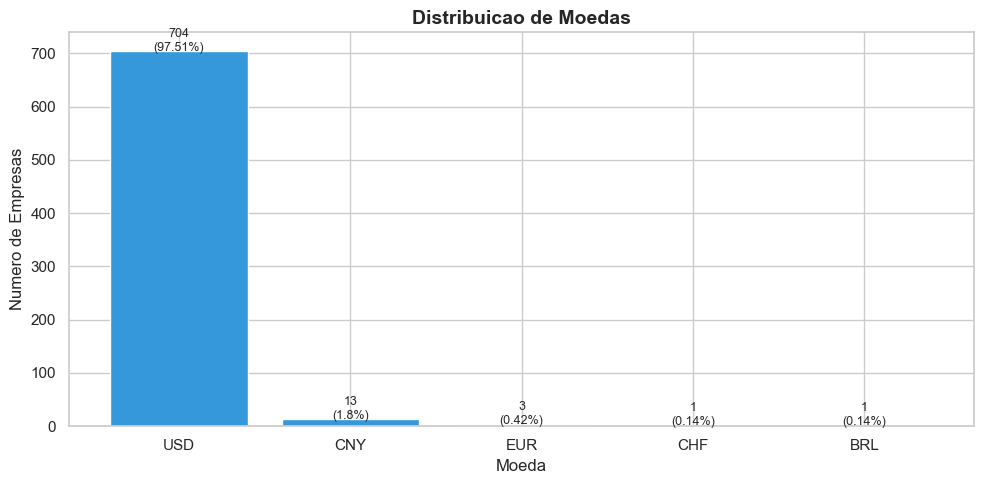

In [6]:
moedas = (
    df["currency"]
    .value_counts()
    .reset_index()
)
moedas.columns = ["Moeda", "Quantidade"]
moedas["Percentual (%)"] = (moedas["Quantidade"] / len(df) * 100).round(2)

print("DISTRIBUICAO DE MOEDAS:")
display(moedas)

# Visualizacao — barras
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(moedas["Moeda"], moedas["Quantidade"], color="#3498db")
ax.set_title("Distribuicao de Moedas", fontsize=14, fontweight="bold")
ax.set_xlabel("Moeda")
ax.set_ylabel("Numero de Empresas")

for i, (qtd, pct) in enumerate(zip(moedas["Quantidade"], moedas["Percentual (%)"])):
    ax.text(i, qtd + 1, f"{qtd}\n({pct}%)", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../docs/viz_03_distribuicao_moedas.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
moedas_raras = moedas[moedas["Quantidade"] == 1]["Moeda"].tolist()

print(f"Moedas com apenas uma empresa: {moedas_raras}\n")

empresas_raras = df[df["currency"].isin(moedas_raras)][
    ["name", "ticker", "exchange", "currency", "industry", "total_score", "total_level"]
].sort_values("currency")

print("Empresas identificadas:")
display(empresas_raras)

Moedas com apenas uma empresa: ['CHF', 'BRL']

Empresas identificadas:


,name,ticker,exchange,currency,industry,total_score,total_level
83,Afya Ltd,afya,NASDAQ NMS - GLOBAL MARKET,BRL,Diversified Consumer Services,698,Medium
37,AC Immune SA,aciu,NASDAQ NMS - GLOBAL MARKET,CHF,Biotechnology,851,Medium


> Podemos observar que neste dataset, a maioria absoluta (97,5%) das empresas estão alocadas em dólar americano (USD), e com apenas uma empresa brasileira (BRL), a Afya Ltd e uma Suíça (CHF) a AC Immune SA. Moedas com baixa representatividade podem distorcer análises comparativas por moeda

#### 5.1.2 Distribuição de Moedas

Permite identificar quais segmentos estão mais representados e possíveis vieses de amostragem.

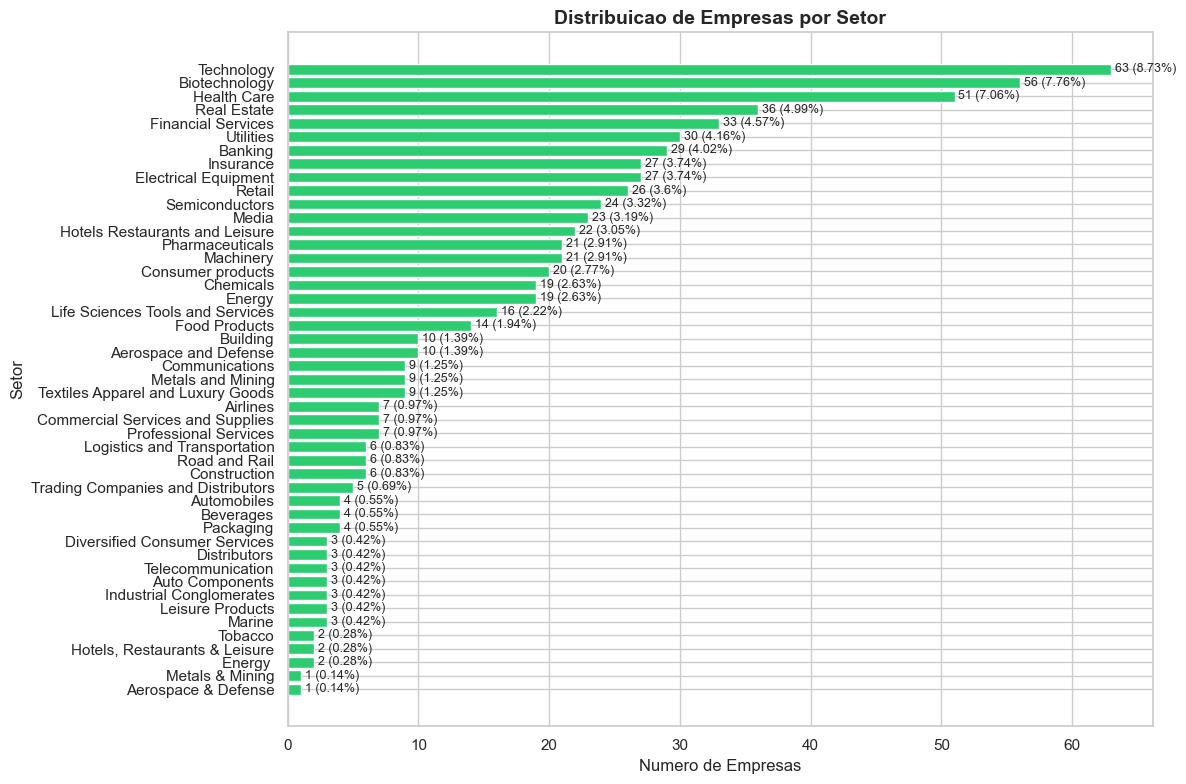

In [8]:
setores = (
    df["industry"]
    .value_counts()
    .reset_index()
)
setores.columns = ["Setor", "Quantidade"]
setores["Percentual (%)"] = (setores["Quantidade"] / len(df) * 100).round(2)

# Visualização — gráfico horizontal para melhor leitura dos nomes
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(setores["Setor"], setores["Quantidade"], color="#2ecc71")
ax.set_title("Distribuicao de Empresas por Setor", fontsize=14, fontweight="bold")
ax.set_xlabel("Numero de Empresas")
ax.set_ylabel("Setor")
ax.invert_yaxis()

for i, (qtd, pct) in enumerate(zip(setores["Quantidade"], setores["Percentual (%)"])):
    ax.text(qtd + 0.3, i, f"{qtd} ({pct}%)", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../docs/viz_04_distribuicao_setores.png", dpi=150, bbox_inches="tight")
plt.show()

> **Interpretação:**
- Setores com maior representatividade têm análises mais confiáveis
- Setores com poucos representantes devem ser interpretados com cautela
- Desequilíbrio entre setores é esperado e reflete a composição real do mercado

#### 5.1.3 Tendência Central e Dispersão dos Scores ESG

Objetivo de mostrar onde os dados se concentram e o quão espalhados estão ao redor desse centro.

In [9]:
cols_scores = [
    "environment_score",
    "social_score",
    "governance_score",
    "total_score"
]

# Calcula estatísticas manualmente para ter controle total sobre o que exibir
descritiva = pd.DataFrame({
    "Média"              : df[cols_scores].mean(),
    "Mediana"            : df[cols_scores].median(),
    "Moda"               : df[cols_scores].mode().iloc[0],
    "Desvio Padrão"      : df[cols_scores].std(),
    "Mínimo"             : df[cols_scores].min(),
    "Máximo"             : df[cols_scores].max(),
    "Coef. Variação (%)" : (df[cols_scores].std() / df[cols_scores].mean() * 100),
}).round(2)

descritiva.index = ["Ambiental", "Social", "Governança", "Total"]

print("TENDENCIA CENTRAL E DISPERSAO DOS SCORES ESG:")
display(descritiva)

TENDENCIA CENTRAL E DISPERSAO DOS SCORES ESG:


,Média,Mediana,Moda,Desvio Padrão,Mínimo,Máximo,Coef. Variação (%)
Ambiental,404.81,483.00,500,145.10,200,719,35.85
Social,292.18,302.00,300,57.02,160,667,19.51
Governança,278.76,300.00,300,47.03,75,475,16.87
Total,975.75,1046.00,1100,218.75,600,1536,22.42


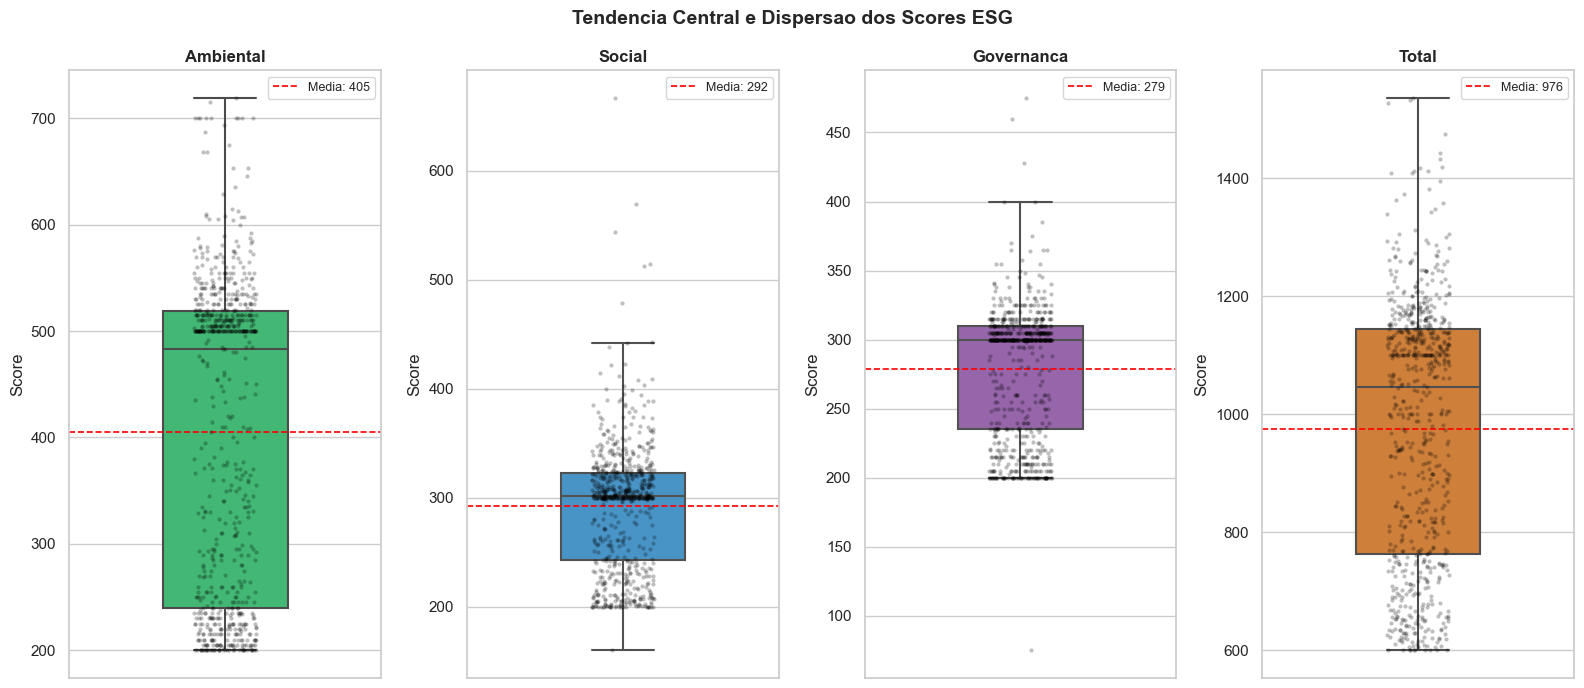

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 7))
fig.suptitle("Tendencia Central e Dispersao dos Scores ESG", 
             fontsize=14, fontweight="bold")

cores = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22"]
titulos = ["Ambiental", "Social", "Governanca", "Total"]

for ax, col, cor, titulo in zip(axes, cols_scores, cores, titulos):
    # Boxplot
    sns.boxplot(
        y=df[col],
        ax=ax,
        color=cor,
        width=0.4,
        fliersize=0,        # esconde os outliers do boxplot pois o stripplot ja os mostra
        linewidth=1.5
    )
    # Pontos individuais sobrepostos
    sns.stripplot(
        y=df[col],
        ax=ax,
        color="black",
        alpha=0.25,         # transparencia para visualizar sobreposicao
        size=3,
        jitter=True         # dispersao horizontal para nao empilhar pontos
    )
    # Linha da média
    media = df[col].mean()
    ax.axhline(media, color="red", linestyle="--", linewidth=1.2, label=f"Media: {media:.0f}")

    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../docs/viz_05_boxplot_scores.png", dpi=150, bbox_inches="tight")
plt.show()

>**Interpretação:**

**Premissas**
- A linha central da caixa representa a mediana
- A linha vermelha tracejada representa a média
- Quando média e mediana estão distantes, indica assimetria na distribuição
- Pontos muito acima ou abaixo da caixa são candidatos a outliers
- A altura da caixa (IQR) mostra onde estão os 50% centrais das empresas

**Resultados**

***<u>Score Ambiental</u>***

- Tem a maior dispersão de todos, com pontos espalhados de 200 a 700+
- Média (405) abaixo da mediana (~480), demonstrando distribuição assimétrica à esquerda, puxada por empresas com baixa performance ambiental
- <u>Esta se mostra como a dimensão onde as empresas mais se diferenciam entre si</u>

***<u>Score Social</u>***

- Distribuição mais concentrada e simétrica, com média e mediana bem próximas (~292 e ~300)
- Há poucos outliers extremos
- <u>Logo, empresas tendem a convergir em performance social</u>

***<u>Score Governança</u>***

- Demosntra a menor amplitude de todas as dimensões
- Ou seja, caixa compacta com empresas com comportamento mais homogêneo em governança
- Média (279) ligeiramente abaixo da mediana (~295)

***<u>Score Total </u>***

- Reflete a soma dos três, portanto, dispersão moderada
- Média (976) abaixo da mediana (~1030), assimetria puxada pelo score ambiental
- Outliers superiores bem visíveis, havendo empresas excepcionalmente bem avaliadas   


>**Conclusão**
>
>O score ambiental demonstra ser o fator principal de diferenciação entre empresas. Já a Governança é onde há mais homogeneidade. O que sugere que os modelos de classificação terão no score ambiental sua feature mais discriminante.
>   



#### 5.4 Média dos scores por setor

Será feita a comparação da performance ESG média entre os diferentes setores da industria. Permite identificar se correlação entre setor e performance, se há segmentos lideram e quais ficam abaixo da média geral.
Conforme avaliação no item 4. Qualidade dos Dados, os nomes de setores tinham duplicidade e serão normalizados temporariamente para fins de análise, ficando a correção definitiva para ser aplicada na camada Silver.

In [ ]:
def normalizar_setor(texto):
    """
    Normalização temporária para análise — não altera o dataframe original.
    """
    if pd.isna(texto):
        return texto
    texto = texto.strip()
    texto = re.sub(r"[&]+", "and", texto)
    texto = re.sub(r"[,\.]+", " ", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

# Cria coluna temporaria normalizada — df original intacto
industry_normalizada = df["industry"].apply(normalizar_setor)

cols_scores = ["environment_score", "social_score", "governance_score", "total_score"]

media_setor = (
    df[cols_scores]
    .assign(industry=industry_normalizada)
    .groupby("industry")[cols_scores]
    .mean()
    .round(2)
    .sort_values("total_score", ascending=False)
    .reset_index()
)
media_setor.columns = ["Setor", "Ambiental", "Social", "Governanca", "Total"]

print("MÉDIA DOS SCORES ESG POR SETOR (normalização temporária):")
display(media_setor)

MEDIA DOS SCORES ESG POR SETOR (normalizacao temporaria):


,Setor,Ambiental,Social,Governanca,Total
0,Utilities,550.97,357.40,282.27,1190.63
1,Tobacco,510.00,327.00,328.00,1165.00
2,Industrial Conglomerates,534.67,318.00,304.33,1157.00
3,Packaging,536.25,323.00,296.75,1156.00
4,Food Products,516.57,311.29,303.21,1131.07
5,Energy,515.10,308.95,293.71,1117.76
6,Distributors,525.00,277.00,307.67,1109.67
7,Construction,495.33,306.17,281.17,1082.67
8,Road and Rail,452.83,326.33,297.17,1076.33
9,Building,476.70,305.10,292.40,1074.20


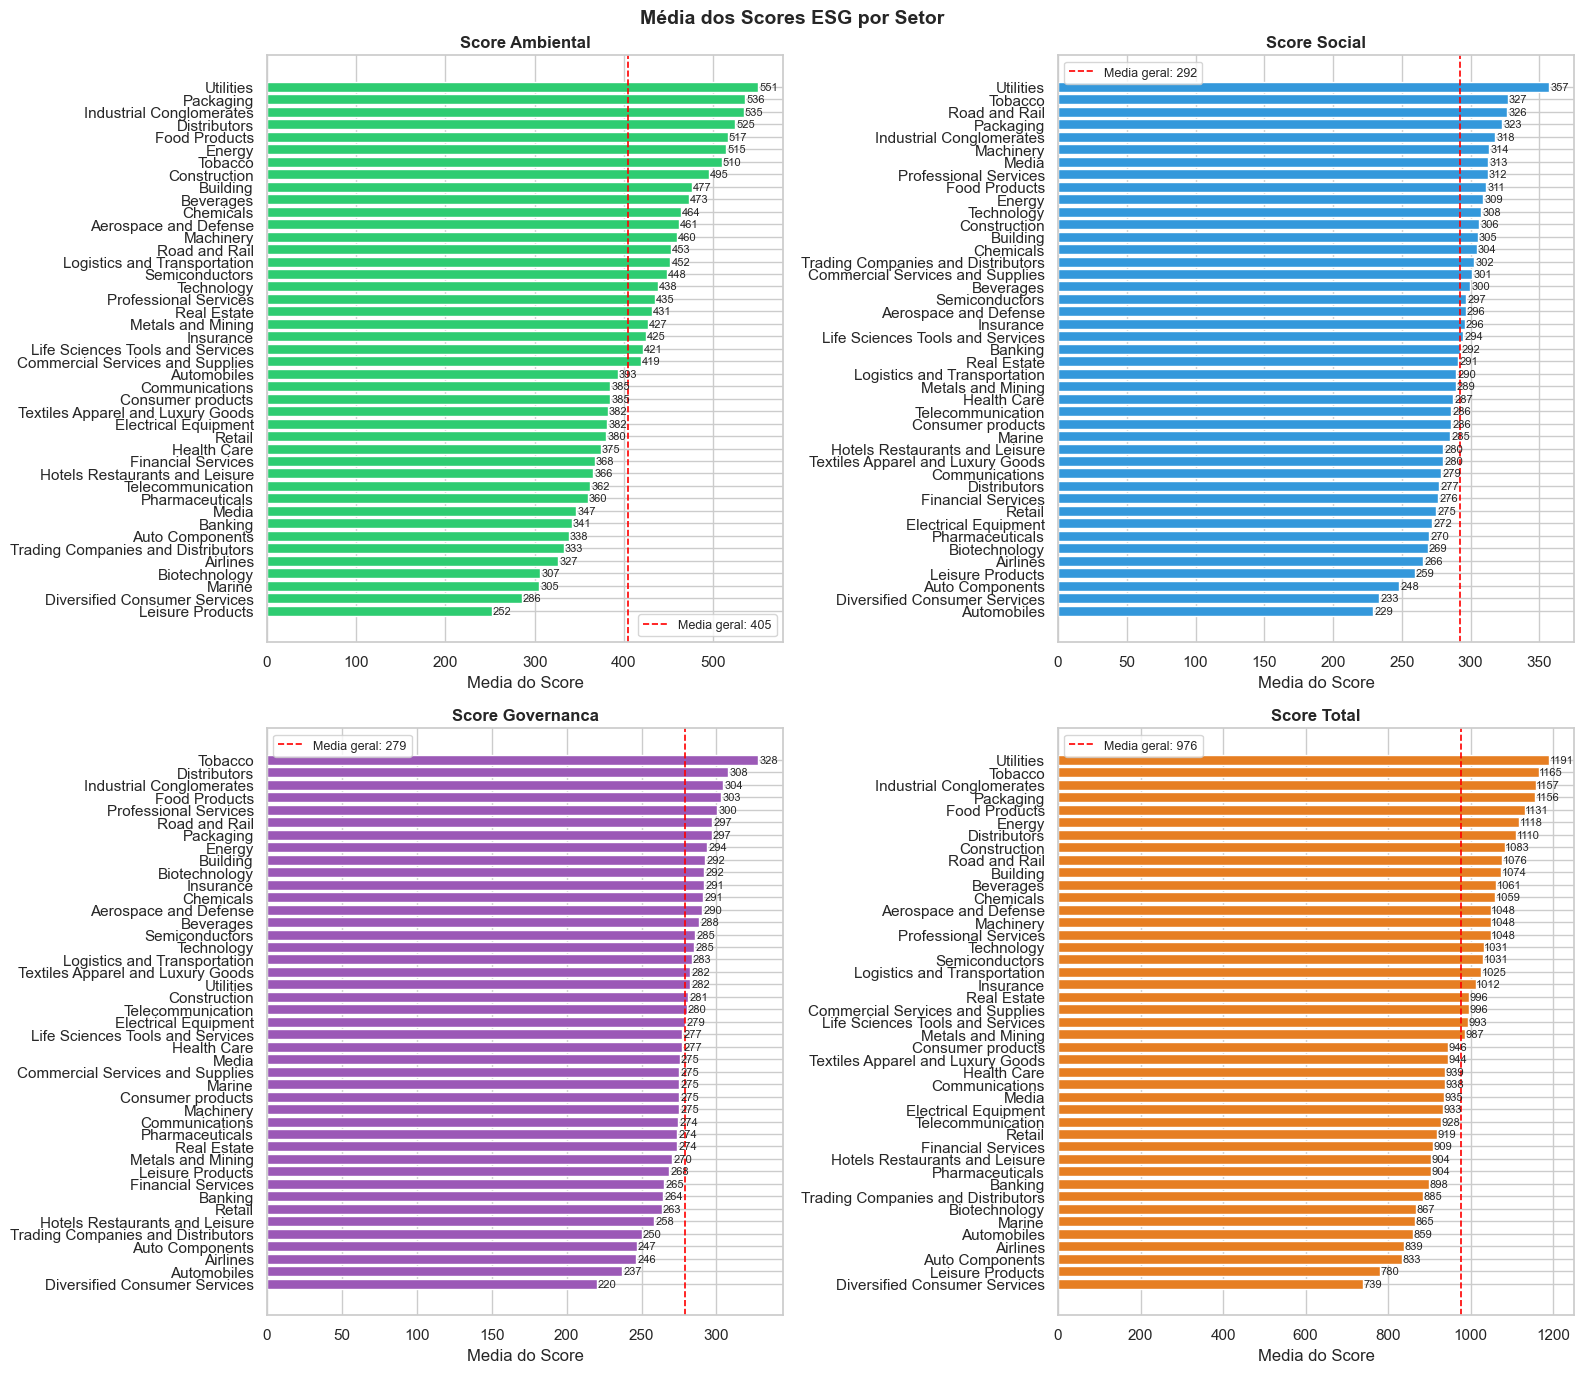

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Média dos Scores ESG por Setor", fontsize=14, fontweight="bold")

colunas_plot = ["Ambiental", "Social", "Governanca", "Total"]
cores = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22"]

for ax, coluna, cor in zip(axes.flatten(), colunas_plot, cores):
    dados = media_setor.sort_values(coluna, ascending=True)

    bars = ax.barh(dados["Setor"], dados[coluna], color=cor)
    ax.set_title(f"Score {coluna}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Media do Score")
    ax.set_ylabel("")

    media_geral = df[cols_scores[colunas_plot.index(coluna)]].mean()
    ax.axvline(
        media_geral,
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=f"Media geral: {media_geral:.0f}"
    )

    for bar, val in zip(bars, dados[coluna]):
        ax.text(
            val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.0f}", va="center", fontsize=8
        )

    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../docs/viz_06_media_scores_por_setor.png", dpi=150, bbox_inches="tight")
plt.show()

>**Interpretação:**

**Premissas**
- A linha vermelha tracejada representa a média geral de todas as empresas
- Setores acima da linha são acima da média do mercado naquela dimensão
- Setores abaixo da linha requerem maior atenção na gestão de risco ESG
- Variações entre dimensões (E, S, G) dentro do mesmo setor revelam pontos fortes e vulnerabilidades específicas de cada segmento

**Resultados**

***<u>Desempenho em total score</u>***

- Setores de **Utilidades**, **Tabaco** e **Conclomerado Industriais**, respectivamente nas primeiras três posições.
- Setores de **Serviços de Consumo Diversos**, **Produtos de Lazer** e **Linhas aéreas**, respectivamente nas últimas três posições.

***<u>Dimensão Ambiental com maior variação</u>***

- Conforme já levantado anteriormente no gráfico de *boxplot*, a área ambiental possui a maior variação, onde o líder **Utilidades** têm score de 550, enquanto a última posição **Produtos de Lazer** com score de 252, mais que a metade.

#### 5.5 Quartis, Percentis e Outliers

Analise de posicao e identificacao de empresas com comportamento
anomalo em relacao ao grupo. Utiliza o metodo IQR (Intervalo
Interquartil) — distancia entre o 1o e o 3o quartil — para
definir os limites aceitaveis de variacao.

In [34]:
cols_scores = ["environment_score", "social_score", "governance_score", "total_score"]

percentis = df[cols_scores].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).T
percentis.columns = ["P10", "Q1 (P25)", "Mediana (P50)", "Q3 (P75)", "P90"]
percentis["IQR"] = percentis["Q3 (P75)"] - percentis["Q1 (P25)"]
percentis["Limite Inferior"] = (percentis["Q1 (P25)"] - 1.5 * percentis["IQR"]).round(2)
percentis["Limite Superior"] = (percentis["Q3 (P75)"] + 1.5 * percentis["IQR"]).round(2)

percentis.index = ["Ambiental", "Social", "Governanca", "Total"]

print("QUARTIS, PERCENTIS E LIMITES IQR:")
display(percentis.round(2))

QUARTIS, PERCENTIS E LIMITES IQR:


,P10,Q1 (P25),Mediana (P50),Q3 (P75),P90,IQR,Limite Inferior,Limite Superior
Ambiental,210.00,240.00,483.00,518.75,555.00,278.75,-178.12,936.88
Social,208.00,243.00,302.00,322.75,348.00,79.75,123.38,442.38
Governanca,205.00,235.00,300.00,310.00,320.00,75.00,122.50,422.50
Total,653.00,763.00,1046.00,1144.00,1207.90,381.00,191.50,1715.50


In [36]:
print("EMPRESAS IDENTIFICADAS COMO OUTLIERS POR DIMENSAO:\n")

outliers_total = pd.DataFrame()

for col, rotulo in zip(cols_scores, ["Ambiental", "Social", "Governanca", "Total"]):
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)][
        ["name", "ticker", "industry", col, "total_level"]
    ].copy()
    outliers["dimensao"]  = rotulo
    outliers["direcao"]   = outliers[col].apply(
        lambda x: "Superior" if x > lim_sup else "Inferior"
    )
    outliers["limite_inf"] = round(lim_inf, 2)
    outliers["limite_sup"] = round(lim_sup, 2)
    outliers = outliers.rename(columns={col: "score"})

    print(f"  {rotulo}: {len(outliers)} outliers "
          f"(limite: [{lim_inf:.0f}, {lim_sup:.0f}])")

    outliers_total = pd.concat([outliers_total, outliers])

print(f"\n  Total de ocorrencias de outliers: {len(outliers_total)}")
print(f"  (uma empresa pode ser outlier em mais de uma dimensao)\n")
display(outliers_total.sort_values(["dimensao", "direcao", "score"]).reset_index(drop=True))

EMPRESAS IDENTIFICADAS COMO OUTLIERS POR DIMENSAO:

  Ambiental: 0 outliers (limite: [-178, 937])
  Social: 7 outliers (limite: [123, 442])
  Governanca: 4 outliers (limite: [122, 422])
  Total: 0 outliers (limite: [192, 1716])

  Total de ocorrencias de outliers: 11
  (uma empresa pode ser outlier em mais de uma dimensao)



,name,ticker,industry,score,total_level,dimensao,direcao,limite_inf,limite_sup
0,CMS Energy Corp,cms,Utilities,75,High,Governanca,Inferior,122.50,422.50
1,Akoustis Technologies Inc,akts,Electrical Equipment,428,High,Governanca,Superior,122.50,422.50
2,Amazon.com Inc,amzn,Retail,460,High,Governanca,Superior,122.50,422.50
3,Amphenol Corp,aph,Electrical Equipment,475,High,Governanca,Superior,122.50,422.50
4,Microsoft Corp,msft,Technology,443,High,Social,Superior,123.38,442.38
5,Pinnacle West Capital Corp,pnw,Utilities,479,High,Social,Superior,123.38,442.38
6,Edison International,eix,Utilities,513,High,Social,Superior,123.38,442.38
7,Yelp Inc,yelp,Media,515,High,Social,Superior,123.38,442.38
8,Conocophillips,cop,Energy,544,High,Social,Superior,123.38,442.38
9,Airbnb Inc,abnb,Hotels Restaurants and Leisure,570,High,Social,Superior,123.38,442.38


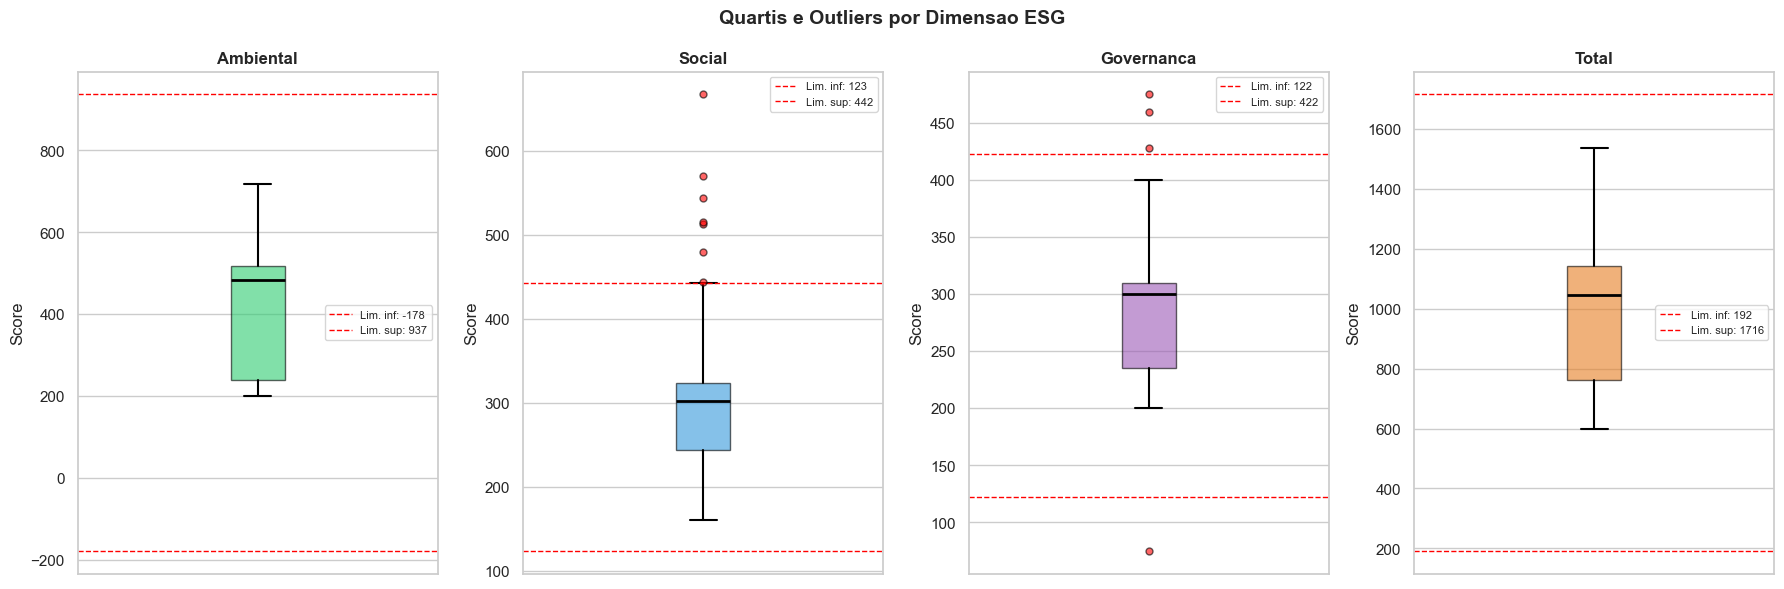

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle("Quartis e Outliers por Dimensao ESG", fontsize=14, fontweight="bold")

cores = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22"]
rotulos = ["Ambiental", "Social", "Governanca", "Total"]

for ax, col, cor, rotulo in zip(axes, cols_scores, cores, rotulos):
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    # Boxplot
    ax.boxplot(
        df[col].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=cor, alpha=0.6),
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker="o", markerfacecolor="red",
                        markersize=5, alpha=0.6),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5)
    )

    # Linhas dos limites IQR
    ax.axhline(lim_inf, color="red", linestyle="--",
               linewidth=1, label=f"Lim. inf: {lim_inf:.0f}")
    ax.axhline(lim_sup, color="red", linestyle="--",
               linewidth=1, label=f"Lim. sup: {lim_sup:.0f}")

    ax.set_title(rotulo, fontsize=12, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_xticks([])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../docs/viz_07_outliers_iqr.png", dpi=150, bbox_inches="tight")
plt.show()

#Tratamento dos Dados